Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


Load Cleaned Dataset

In [6]:
df = pd.read_csv("netflix-titles-cleaned.csv")

print("Cleaned dataset loaded successfully")

Cleaned dataset loaded successfully


View Dataset

In [7]:
df.head()

,id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


Dataset Size

In [8]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 8807
Number of columns: 12


Dataset Information

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      8807 non-null   object
 4   cast          8807 non-null   object
 5   country       8807 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8807 non-null   object
 9   duration      8804 non-null   object
 10  genres        8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


Descriptive Statistics

In [10]:
df.describe(include="all")

,id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
count,8807,8807,8807,8807,8807,8807,8797,8807.000000,8807,8804,8807,8807
unique,8807,2,8807,4529,7693,749,1714,NaN,18,220,514,8775
top,s8807,Movie,Zubaan,Unknown,Unknown,United States,2020-01-01,NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,2634,825,2818,110,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


Movies vs TV Shows

In [11]:
print(df["type"].value_counts())

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


Visualization 1

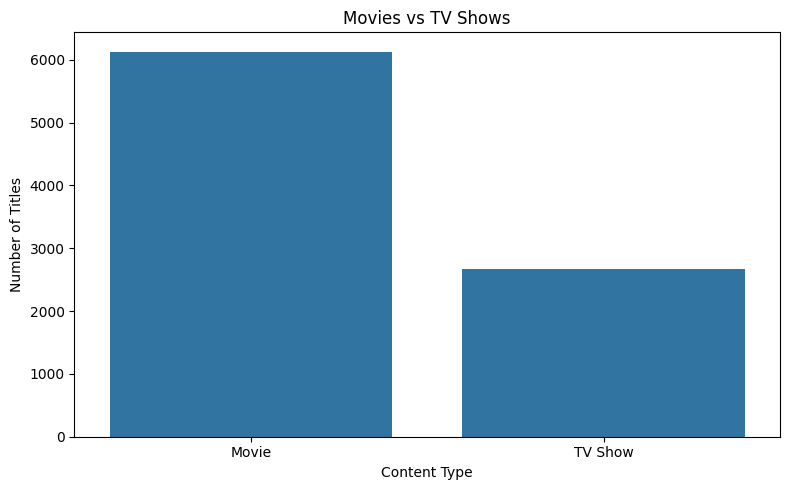

In [12]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="type")

plt.title("Movies vs TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.show()

Content by Release Year

In [13]:
release_year_counts = df["release_year"].value_counts().sort_index()

print(release_year_counts.tail(10))

release_year
2012     237
2013     288
2014     352
2015     560
2016     902
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, dtype: int64


Visualization 2

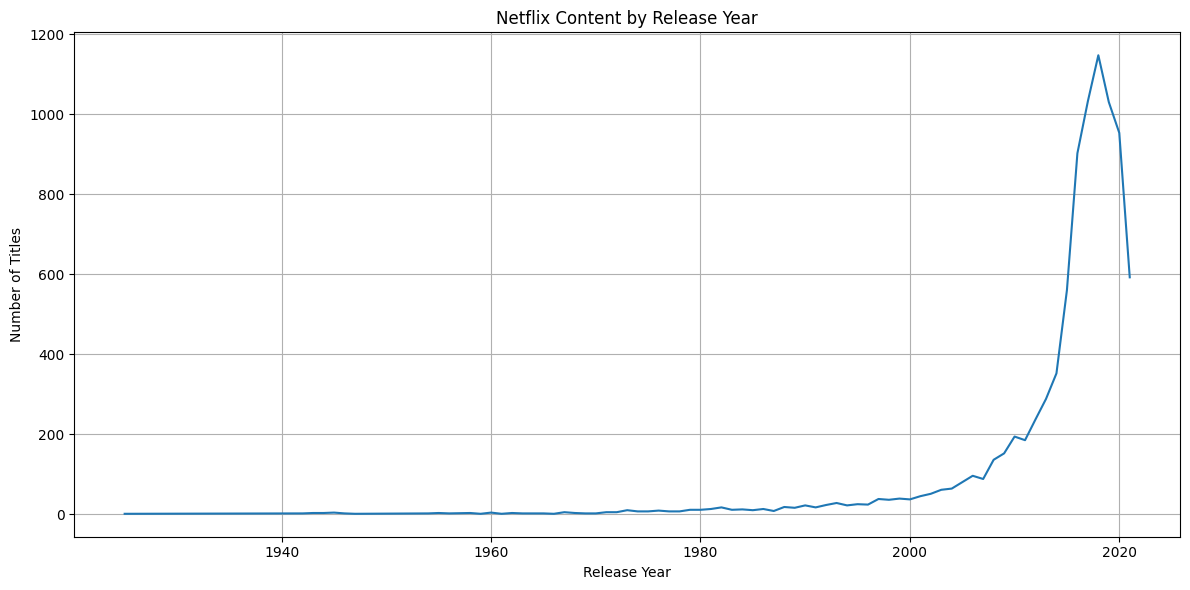

In [14]:
plt.figure(figsize=(12, 6))

plt.plot(
    release_year_counts.index,
    release_year_counts.values
)

plt.title("Netflix Content by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.grid(True)
plt.tight_layout()
plt.show()

TOP COUNTRIES




In [20]:
country_counts = (
    df["country"]
    .str.split(", ")
    .explode()
    .value_counts()
)

print(country_counts.head(10))

country
United States     3689
India             1046
Unknown            831
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64


Visualization 3

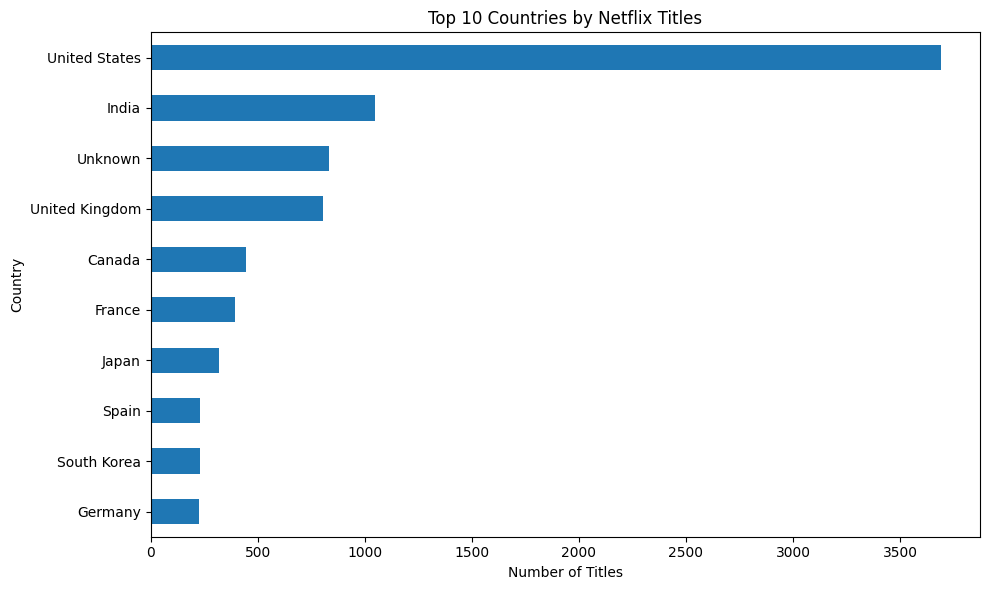

In [18]:
plt.figure(figsize=(10, 6))

country_counts.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Countries by Netflix Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

Business Analysis

In [21]:
print("===== BUSINESS ANALYSIS ====")

print("Total Titles:", len(df))

print("\nMovies vs TV Shows:")
print(df["type"].value_counts())

print("\nTop 5 Countries:")
print(country_counts.head(5))

genre_counts = df["genres"].str.split(", ").explode().value_counts()
print("\nTop 5 Genres:")
print(genre_counts.head(5))

print("\nTop 5 Ratings:")
print(df["rating"].value_counts().head(5))

print("\nTop 5 Release Years:")
print(df["release_year"].value_counts().head(5))

===== BUSINESS ANALYSIS ====
Total Titles: 8807

Movies vs TV Shows:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64

Top 5 Countries:
country
United States     3689
India             1046
Unknown            831
United Kingdom     804
Canada             445
Name: count, dtype: int64

Top 5 Genres:
genres
International Movies      2752
Dramas                    2427
Comedies                  1674
International TV Shows    1351
Documentaries              869
Name: count, dtype: int64

Top 5 Ratings:
rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
Name: count, dtype: int64

Top 5 Release Years:
release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
Name: count, dtype: int64


5 Business Insights

In [23]:
movie_count = (df["type"] == "Movie").sum()
tv_count = (df["type"] == "TV Show").sum()

top_country = country_counts.index[0]
top_genre = genre_counts.index[0]
top_rating = df["rating"].value_counts().index[0]
top_release_year = df["release_year"].value_counts().index[0]

print("===== BUSINESS INSIGHTS =====")

print(f"1. The dataset contains {movie_count} Movies and {tv_count} TV Shows.")

print(f"2. {top_country} has the highest number of titles in the dataset.")

print(f"3. {top_genre} is the most common genre.")

print(f"4. {top_rating} is the most common content rating.")

print(f"5. {top_release_year} is the release year with the highest number of titles.")

===== BUSINESS INSIGHTS =====
1. The dataset contains 6131 Movies and 2676 TV Shows.
2. United States has the highest number of titles in the dataset.
3. International Movies is the most common genre.
4. TV-MA is the most common content rating.
5. 2018 is the release year with the highest number of titles.
